# Electricity Distribution Network Fault Analysis and Prediction

### Spatial–Temporal Analysis using Hotspot Detection and ARIMA Forecasting

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import os
os.makedirs("../results/figures", exist_ok=True)

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from shapely.geometry import box

# Time series models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Spatial statistics
from esda.getisord import G_Local
from libpysal.weights import Queen

In [2]:
#Load the Dataset
df = pd.read_csv("C:/Users/Dilakna Godagamage/Documents/KDU/3rd year/Data visualization and story telling/Assignments/Assignment I/Electricity_Fault_Project/data/ukpn-iis.csv")

In [3]:
df.head()

,Incident Reference,Restoration Stage,Start Date and Time,End Date and Time,Number of Customers Restored,Re-interruption Stage,MEI code,Cause Code,Continued Cause Code,Damage to the Network,Exceptional Event?,incident_count,Whether or not this incident was excluded from the IIS,ee_coding_only_for_additional_incidents,licence_area,regulatory_year,unique_identifier,substation,SiteFunctionalLocation,Spatial Coordinates
0,FREP-233061-Z,3,2021-04-25T20:26:00+05:30,2021-04-25T21:07:00+05:30,7,Y,90,87,NaN,0,NaN,0,NaN,NaN,EPN,2021-22,FREP-233061-Z3,LINDSEY ST PRIMARY,EPN-S0000000H7152,"51.7043064090065, 0.115333755355965"
1,FREP-232518-Z,1,2021-04-21T22:22:00+05:30,2021-04-21T23:12:00+05:30,23,N,S3,97,NaN,0,NaN,1,NaN,NaN,EPN,2021-22,FREP-232518-Z1,HIGHFIELD PRIMARY,EPN-S0000000H1006,"52.0769542169972, 1.12812127222429"
2,FREP-232704-Z,2,2021-04-23T02:01:00+05:30,2021-04-23T02:04:00+05:30,9,N,X,86,NaN,0,NaN,0,NaN,NaN,EPN,2021-22,FREP-232704-Z2,MANOR ROAD PRIMARY,EPN-S0000000H1017,"52.1004993530862, 1.29602655758309"
3,FREP-232909-Z,5,2021-04-23T23:06:00+05:30,2021-04-24T03:46:00+05:30,10,Y,41,71,NaN,1,NaN,0,NaN,NaN,EPN,2021-22,FREP-232909-Z5,RADLETT PRIMARY,EPN-S0000000N8124,"51.6823488121623, -0.313761512631864"
4,FREP-233497-Z,2,2021-04-27T21:00:00+05:30,2021-04-28T01:10:00+05:30,1,N,41,71,NaN,1,NaN,0,NaN,NaN,EPN,2021-22,FREP-233497-Z2,HUNTINGDON GRID,EPN-S0000000F4068,"52.3407372864036, -0.183060686204365"


In [4]:
#Check dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237901 entries, 0 to 237900
Data columns (total 20 columns):
 #   Column                                                  Non-Null Count   Dtype  
---  ------                                                  --------------   -----  
 0   Incident Reference                                      237901 non-null  object 
 1   Restoration Stage                                       237901 non-null  int64  
 2   Start Date and Time                                     237901 non-null  object 
 3   End Date and Time                                       237901 non-null  object 
 4   Number of Customers Restored                            237901 non-null  int64  
 5   Re-interruption Stage                                   237901 non-null  object 
 6   MEI code                                                237901 non-null  object 
 7   Cause Code                                              237901 non-null  object 
 8   Continued Cause Code    

In [5]:
#Convert Date Columns
df['Start Date and Time'] = pd.to_datetime(df['Start Date and Time'])
df['End Date and Time'] = pd.to_datetime(df['End Date and Time'])

In [6]:
#Extract Time Features
df['year'] = df['Start Date and Time'].dt.year
df['month'] = df['Start Date and Time'].dt.month
df['day'] = df['Start Date and Time'].dt.day
df['hour'] = df['Start Date and Time'].dt.hour

In [7]:
#Split Spatial Coordinates
#separate them
df[['latitude','longitude']] = df['Spatial Coordinates'].str.split(',', expand=True)

#Convert to numeric
df['latitude'] = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)

#Remove missing coordinates
df = df.dropna(subset=['latitude','longitude'])

In [8]:
#Save Cleaned Dataset
df.to_csv("C:/Users/Dilakna Godagamage/Documents/KDU/3rd year/Data visualization and story telling/Assignments/Assignment I/Electricity_Fault_Project/results/cleaned_fault_data.csv", index=False)

## Exploratory Data Analysis - EDA

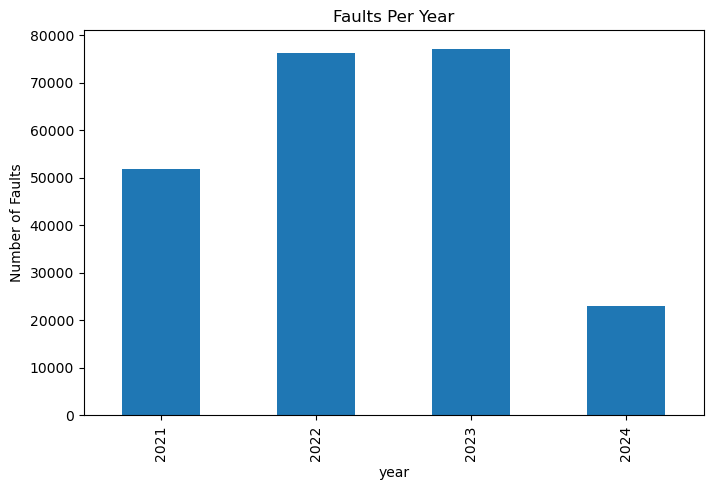

In [9]:
#Faults Per Year
yearly = df.groupby('year').size()

yearly.plot(kind='bar', figsize=(8,5))
plt.title("Faults Per Year")
plt.ylabel("Number of Faults")

plt.show()

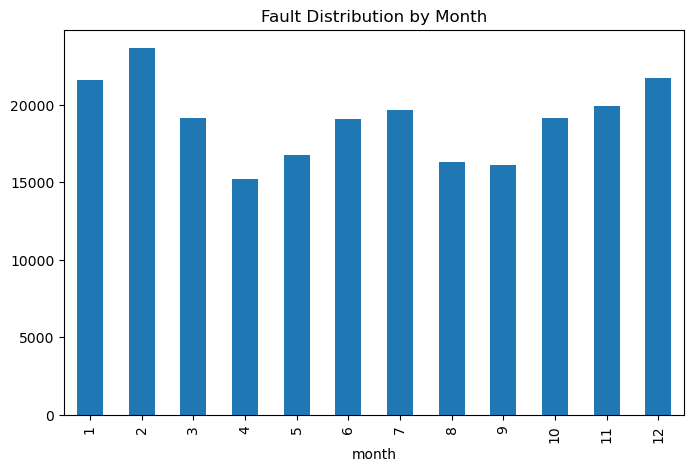

In [10]:
#Faults Per Month
monthly = df.groupby('month').size()

monthly.plot(kind='bar', figsize=(8,5))
plt.title("Fault Distribution by Month")

plt.show()

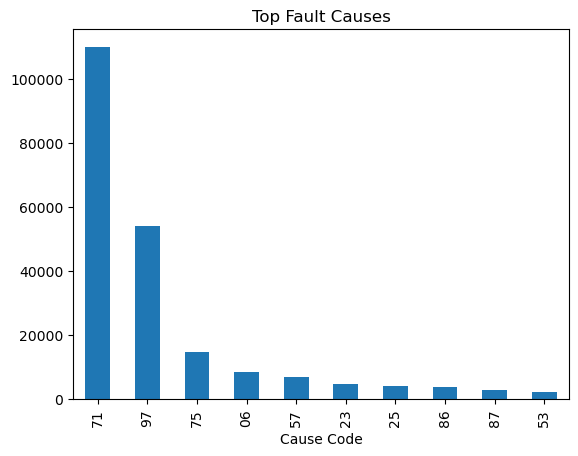

In [11]:
#Top Causes of Faults
top_causes = df['Cause Code'].value_counts().head(10)

top_causes.plot(kind='bar')
plt.title("Top Fault Causes")

plt.show()

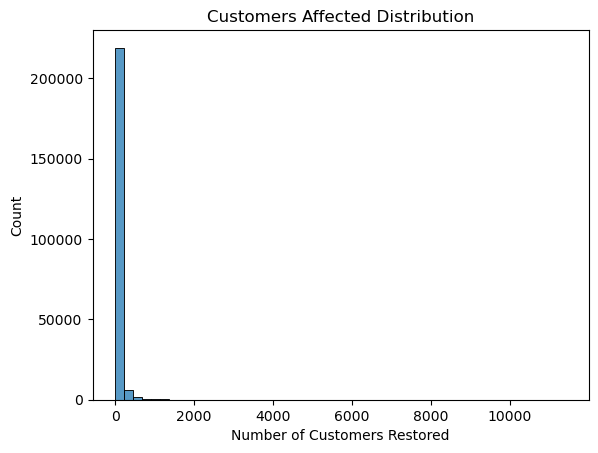

In [12]:
#Customers Impacted
df['Number of Customers Restored'].describe()

## Plot distribution
sns.histplot(df['Number of Customers Restored'], bins=50)

plt.title("Customers Affected Distribution")
plt.show()


## Spatial Mapping

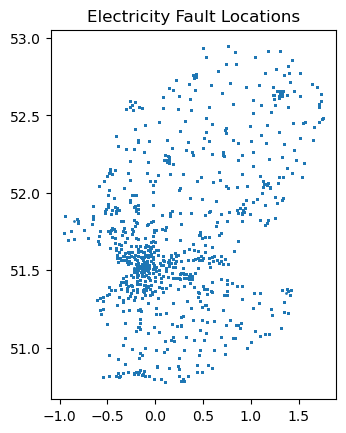

In [13]:
#Convert dataset to geospatial
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)
## Plot fault locations.
gdf.plot(markersize=1)

plt.title("Electricity Fault Locations")
plt.show()

## Create Spatial Grid

In [14]:
#this allows hotspot detection;

xmin, ymin, xmax, ymax = gdf.total_bounds

cell_size = 0.05

cols = list(np.arange(xmin, xmax + cell_size, cell_size))
rows = list(np.arange(ymin, ymax + cell_size, cell_size))

##create grid cells
from shapely.geometry import box

polygons = []

for x in cols[:-1]:
    for y in rows[:-1]:
        polygons.append(box(x,y,x+cell_size,y+cell_size))

grid = gpd.GeoDataFrame({'geometry':polygons}, crs="EPSG:4326")

## Count Faults per Grid

In [15]:
joined = gpd.sjoin(gdf, grid, how="left")

fault_counts = joined.groupby("index_right").size()

grid['fault_count'] = fault_counts
grid['fault_count'] = grid['fault_count'].fillna(0)

## Getis-Ord Gi* Hotspot Analysis

In [16]:
# Remove empty grid cells
grid = grid[grid['fault_count'] > 0]

In [17]:
# Create spatial weights
w = Queen.from_dataframe(grid, use_index=False)

# Row-standardize weights
w.transform = 'r'

# Run Getis-Ord Gi*
gi = G_Local(grid['fault_count'], w)

# Attach results to grid
grid['GiZScore'] = gi.Zs
grid['GiPValue'] = gi.p_sim


C:\ProgramData\anaconda3\envs\dsproject\lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 248 disconnected components.
 There are 151 islands with ids: 2, 29, 30, 33, 34, 41, 42, 51, 54, 55, 61, 62, 67, 78, 79, 87, 88, 92, 95, 96, 109, 110, 111, 114, 115, 131, 132, 133, 134, 135, 146, 147, 148, 149, 150, 159, 162, 163, 164, 165, 176, 182, 183, 195, 196, 197, 198, 205, 206, 207, 215, 225, 226, 227, 228, 236, 242, 243, 244, 250, 251, 254, 260, 265, 266, 267, 270, 271, 277, 280, 281, 286, 287, 288, 289, 292, 295, 296, 297, 300, 301, 302, 303, 304, 305, 308, 318, 319, 348, 359, 360, 376, 386, 387, 392, 396, 408, 419, 423, 425, 426, 427, 430, 434, 435, 436, 437, 438, 442, 443, 444, 448, 449, 450, 451, 452, 453, 456, 457, 460, 461, 462, 466, 467, 468, 469, 470, 471, 472, 475, 480, 481, 482, 483, 486, 487, 488, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 505, 511.
  W.__init__(self, neighbors, ids=ids, **k

('WARNING: ', 2, ' is an island (no neighbors)')
('WARNING: ', 29, ' is an island (no neighbors)')
('WARNING: ', 30, ' is an island (no neighbors)')
('WARNING: ', 33, ' is an island (no neighbors)')
('WARNING: ', 34, ' is an island (no neighbors)')
('WARNING: ', 41, ' is an island (no neighbors)')
('WARNING: ', 42, ' is an island (no neighbors)')
('WARNING: ', 51, ' is an island (no neighbors)')
('WARNING: ', 54, ' is an island (no neighbors)')
('WARNING: ', 55, ' is an island (no neighbors)')
('WARNING: ', 61, ' is an island (no neighbors)')
('WARNING: ', 62, ' is an island (no neighbors)')
('WARNING: ', 67, ' is an island (no neighbors)')
('WARNING: ', 78, ' is an island (no neighbors)')
('WARNING: ', 79, ' is an island (no neighbors)')
('WARNING: ', 87, ' is an island (no neighbors)')
('WARNING: ', 88, ' is an island (no neighbors)')
('WARNING: ', 92, ' is an island (no neighbors)')
('WARNING: ', 95, ' is an island (no neighbors)')
('WARNING: ', 96, ' is an island (no neighbors)')
(

C:\ProgramData\anaconda3\envs\dsproject\lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim


## Plot the Hotspot Map

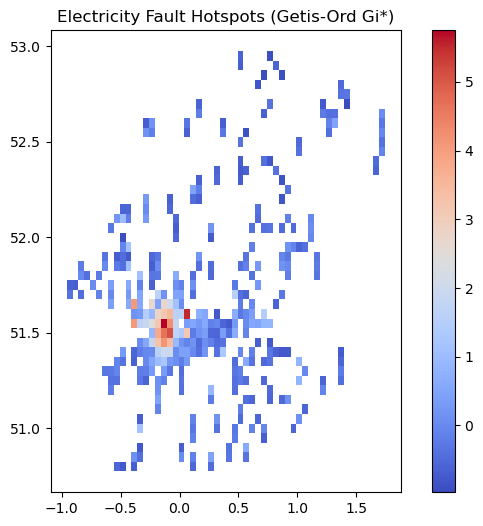

In [18]:
grid.plot(
    column='GiZScore',
    cmap='coolwarm',
    legend=True,
    figsize=(8,6)
)

plt.title("Electricity Fault Hotspots (Getis-Ord Gi*)")

plt.savefig("C:/Users/Dilakna Godagamage/Documents/KDU/3rd year/Data visualization and story telling/Assignments/Assignment I/Electricity_Fault_Project/results/figures/hotspot_map.png", dpi=300)

plt.show()

In [19]:
## Save Results
grid.to_csv("C:/Users/Dilakna Godagamage/Documents/KDU/3rd year/Data visualization and story telling/Assignments/Assignment I/Electricity_Fault_Project/results/hotspot_results.csv")

## Time Series Preparation

In [20]:
#Aggregate faults monthly
time_series = df.resample('ME', on='Start Date and Time').size()

time_series = time_series.to_frame(name='fault_count')

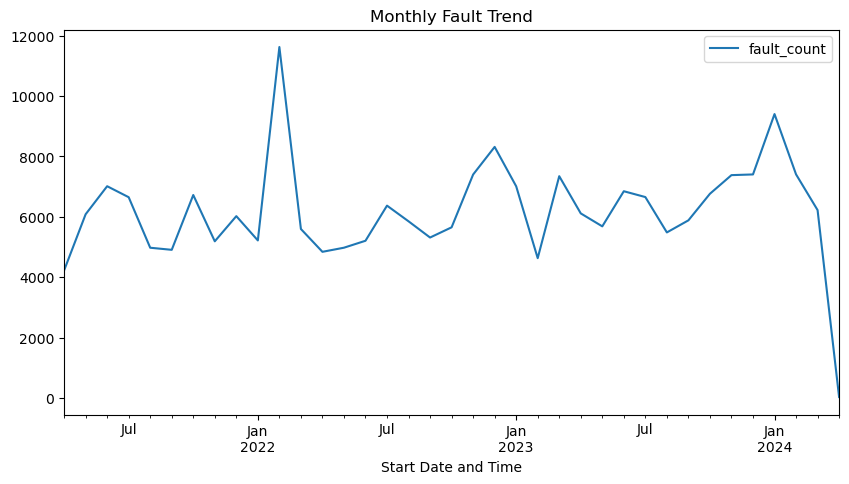

In [21]:
#Plot
time_series.plot(figsize=(10,5))

plt.title("Monthly Fault Trend")
plt.show()

## ARIMA Forecasting

In [22]:
#Train model
model = ARIMA(time_series['fault_count'], order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            fault_count   No. Observations:                   37
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -323.640
Date:                Sat, 14 Mar 2026   AIC                            653.279
Time:                        12:12:38   BIC                            658.030
Sample:                    04-30-2021   HQIC                           654.937
                         - 04-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3124      0.235      1.327      0.184      -0.149       0.774
ma.L1         -0.9996      0.134     -7.439      0.000      -1.263      -0.736
sigma2      3.407e+06   3.93e-08   8.67e+13      0.0

## Predict Future Faults

In [23]:
#Forecast 12 months
forecast = model_fit.forecast(steps=12)

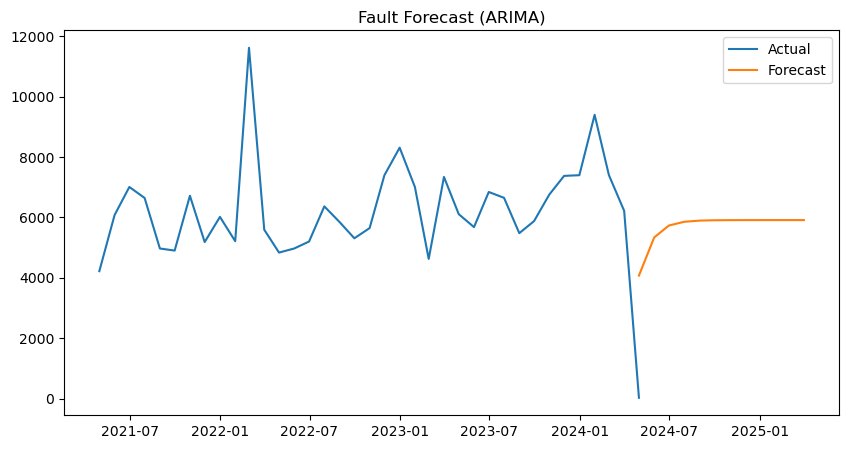

In [24]:
#Plot forecast
plt.figure(figsize=(10,5))

plt.plot(time_series.index, time_series['fault_count'], label='Actual')

future_dates = pd.date_range(time_series.index[-1], periods=12, freq='ME')

plt.plot(future_dates, forecast, label='Forecast')

plt.legend()

plt.title("Fault Forecast (ARIMA)")

plt.savefig("C:/Users/Dilakna Godagamage/Documents/KDU/3rd year/Data visualization and story telling/Assignments/Assignment I/Electricity_Fault_Project/results/figures/forecast_results.png", dpi=300)
plt.show()

In [25]:
#Save predictions
forecast_df = pd.DataFrame({
    'date':future_dates,
    'predicted_faults':forecast
})

forecast_df.to_csv("../results/forecast_results.csv", index=False)